In [10]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO


In [9]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# SAM2 Imports
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# Ensure matplotlib plots inline in Jupyter Notebooks
%matplotlib inline

def calculate_iou(mask1, mask2):
    if mask1 is None or mask2 is None:
        return 0.0
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def calculate_dsc(mask1, mask2):
    if mask1 is None or mask2 is None:
        return 0.0
    intersection = np.logical_and(mask1, mask2).sum()
    total = mask1.sum() + mask2.sum()
    return (2.0 * intersection) / total if total > 0 else 0.0

def box_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return intersection / float(area1 + area2 - intersection)

def plot_5x3_grid(records, model_name, sort_key, mask_key, mask_color):
    """
    Plots a 5x3 grid (5 examples x 3 categories: Best, Average, Worst)
    Cropped around the target for visibility.
    """
    # Sort records to find extreme and average cases
    sorted_records = sorted(records, key=lambda x: x[sort_key])
    n = len(sorted_records)
    
    worst_5 = sorted_records[:5]
    best_5 = sorted_records[-5:][::-1] # Reverse to get absolute best at the top
    
    mid_idx = n // 2
    avg_5 = sorted_records[max(0, mid_idx - 2) : min(n, mid_idx + 3)]
    
    fig, axes = plt.subplots(5, 3, figsize=(15, 20), dpi=150)
    fig.suptitle(f"{model_name} Segmentation Performance (YOLO-Detected Cases)", fontsize=20, y=0.98)
    
    categories = [(best_5, "Best"), (avg_5, "Average"), (worst_5, "Worst")]
    
    for col, (cat_records, cat_name) in enumerate(categories):
        axes[0, col].set_title(f"{cat_name} Cases", fontsize=16, pad=10)
        
        for row in range(5):
            ax = axes[row, col]
            if row < len(cat_records):
                rec = cat_records[row]
                img = cv2.imread(rec['img_path'])
                mask = rec[mask_key]
                iou = rec[sort_key]
                gt_box = rec['gt_box']
                
                # Apply Mask Overlay (Low Opacity)
                img_disp = img.copy()
                if mask is not None:
                    img_disp[mask] = img_disp[mask] * 0.5 + np.array(mask_color) * 0.5
                    
                # Draw Ground Truth Outline (Thin)
                cv2.polylines(img_disp, [rec['gt_pts']], isClosed=True, color=(0, 255, 0), thickness=1)
                
                # Zoom in on the object with 50% padding
                pad_x = int((gt_box[2] - gt_box[0]) * 0.5)
                pad_y = int((gt_box[3] - gt_box[1]) * 0.5)
                
                x1 = max(0, int(gt_box[0]) - pad_x)
                y1 = max(0, int(gt_box[1]) - pad_y)
                x2 = min(img.shape[1], int(gt_box[2]) + pad_x)
                y2 = min(img.shape[0], int(gt_box[3]) + pad_y)
                
                crop = img_disp[y1:y2, x1:x2]
                
                ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
                ax.set_xlabel(f"IoU: {iou:.3f}", fontsize=12)
                ax.set_xticks([])
                ax.set_yticks([])
                
                # Add a border to delineate subplots
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(1)
            else:
                ax.axis('off')
                
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

def evaluate_detected_cases_only(img_dir, label_dir, yolo_weights, sam2_checkpoint, sam2_config):
    print("Loading Models...")
    yolo_model = YOLO(yolo_weights)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    sam2_model = build_sam2(sam2_config, sam2_checkpoint, device=device)
    sam2_predictor = SAM2ImagePredictor(sam2_model)

    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    valid_extensions = ['.jpg', '.png', '.jpeg', '.JPG', '.PNG']

    metrics = {'sam2_iou': [], 'sam2_dsc': [], 'yolo_iou': [], 'yolo_dsc': []}
    object_records = []
    
    print(f"Scanning {len(label_files)} annotations...")

    for label_filename in label_files:
        base_name = os.path.splitext(label_filename)[0]
        label_path = os.path.join(label_dir, label_filename)
        
        img_path = None
        for ext in valid_extensions:
            temp = os.path.join(img_dir, base_name + ext)
            if os.path.exists(temp):
                img_path = temp
                break
                
        if not img_path:
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img_h, img_w = img.shape[:2]
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        yolo_results = yolo_model.predict(img, retina_masks=True, verbose=False)[0]
        y_boxes, y_masks = [], []
        if yolo_results.boxes is not None and yolo_results.masks is not None:
            y_boxes = yolo_results.boxes.xyxy.cpu().numpy()
            y_masks = yolo_results.masks.data.cpu().numpy().astype(bool)

        sam2_predictor.set_image(img_rgb)

        with open(label_path, 'r') as f:
            lines = f.readlines()

        for obj_idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) < 7:
                continue
                
            coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] *= img_w
            coords[:, 1] *= img_h
            pts = np.int32(coords)
            
            gt_mask = np.zeros((img_h, img_w), dtype=np.uint8)
            cv2.fillPoly(gt_mask, [pts], 1)
            gt_mask = gt_mask.astype(bool)
            
            x_min, y_min = np.min(pts[:, 0]), np.min(pts[:, 1])
            x_max, y_max = np.max(pts[:, 0]), np.max(pts[:, 1])
            gt_box = np.array([x_min, y_min, x_max, y_max])
            
            # --- EVALUATE YOLO (To Filter Undetected Cases) ---
            best_yolo_iou_box = 0.0
            best_y_mask = None
            
            for y_box, y_mask in zip(y_boxes, y_masks):
                b_iou = box_iou(gt_box, y_box)
                if b_iou > 0.5 and b_iou > best_yolo_iou_box:
                    best_yolo_iou_box = b_iou
                    
                    constrained_yolo_mask = np.zeros_like(y_mask)
                    constrained_yolo_mask[int(y_min):int(y_max), int(x_min):int(x_max)] = \
                        y_mask[int(y_min):int(y_max), int(x_min):int(x_max)]
                    best_y_mask = constrained_yolo_mask
            
            # FILTER: Skip this target completely if YOLO failed to detect it
            if best_yolo_iou_box == 0.0 or best_y_mask is None:
                continue
                
            yolo_iou = calculate_iou(gt_mask, best_y_mask)
            yolo_dsc = calculate_dsc(gt_mask, best_y_mask)
            
            # --- EVALUATE SAM2 ---
            sam2_masks, _, _ = sam2_predictor.predict(box=gt_box, multimask_output=False)
            s_mask = sam2_masks[0].astype(bool)
            
            sam2_iou = calculate_iou(gt_mask, s_mask)
            sam2_dsc = calculate_dsc(gt_mask, s_mask)
            
            # Record valid metrics
            metrics['sam2_iou'].append(sam2_iou)
            metrics['sam2_dsc'].append(sam2_dsc)
            metrics['yolo_iou'].append(yolo_iou)
            metrics['yolo_dsc'].append(yolo_dsc)
            
            object_records.append({
                'img_path': img_path,
                'gt_pts': pts,
                'gt_box': gt_box,
                's_mask': s_mask,
                'y_mask': best_y_mask,
                'yolo_iou': yolo_iou,
                'sam2_iou': sam2_iou
            })

    if not object_records:
        print("No valid YOLO detections found to evaluate.")
        return

    # --- CLI Metrics Output ---
    print("\n" + "="*50)
    print("   EVALUATION RESULTS (DETECTED CASES ONLY)")
    print("="*50)
    print(f"Total Objects Evaluated : {len(object_records)}")
    print("-" * 50)
    print("SAM2 Performance:")
    print(f"  Mean Mask IoU         : {np.mean(metrics['sam2_iou']):.4f}")
    print(f"  Mean Mask DSC         : {np.mean(metrics['sam2_dsc']):.4f}")
    print("-" * 50)
    print("YOLO Performance:")
    print(f"  Mean Mask IoU         : {np.mean(metrics['yolo_iou']):.4f}")
    print(f"  Mean Mask DSC         : {np.mean(metrics['yolo_dsc']):.4f}")
    print("="*50)

    # --- Generate Jupyter Visuals ---
    print("\nGenerating visual grids...")
    
    # Grid 1: SAM2 Performance (Red mask overlay)
    plot_5x3_grid(
        records=object_records, 
        model_name="SAM2", 
        sort_key='sam2_iou', 
        mask_key='s_mask', 
        mask_color=[255, 0, 0]
    )
    
    # Grid 2: YOLO Performance (Blue mask overlay)
    plot_5x3_grid(
        records=object_records, 
        model_name="YOLO", 
        sort_key='yolo_iou', 
        mask_key='y_mask', 
        mask_color=[0, 0, 255]
    )


Loading Models...
Scanning 2737 annotations...

   EVALUATION RESULTS (DETECTED CASES ONLY)
Total Objects Evaluated : 813
--------------------------------------------------
SAM2 Performance:
  Mean Mask IoU         : 0.8262
  Mean Mask DSC         : 0.9035
--------------------------------------------------
YOLO Performance:
  Mean Mask IoU         : 0.7207
  Mean Mask DSC         : 0.8283

Generating visual grids...


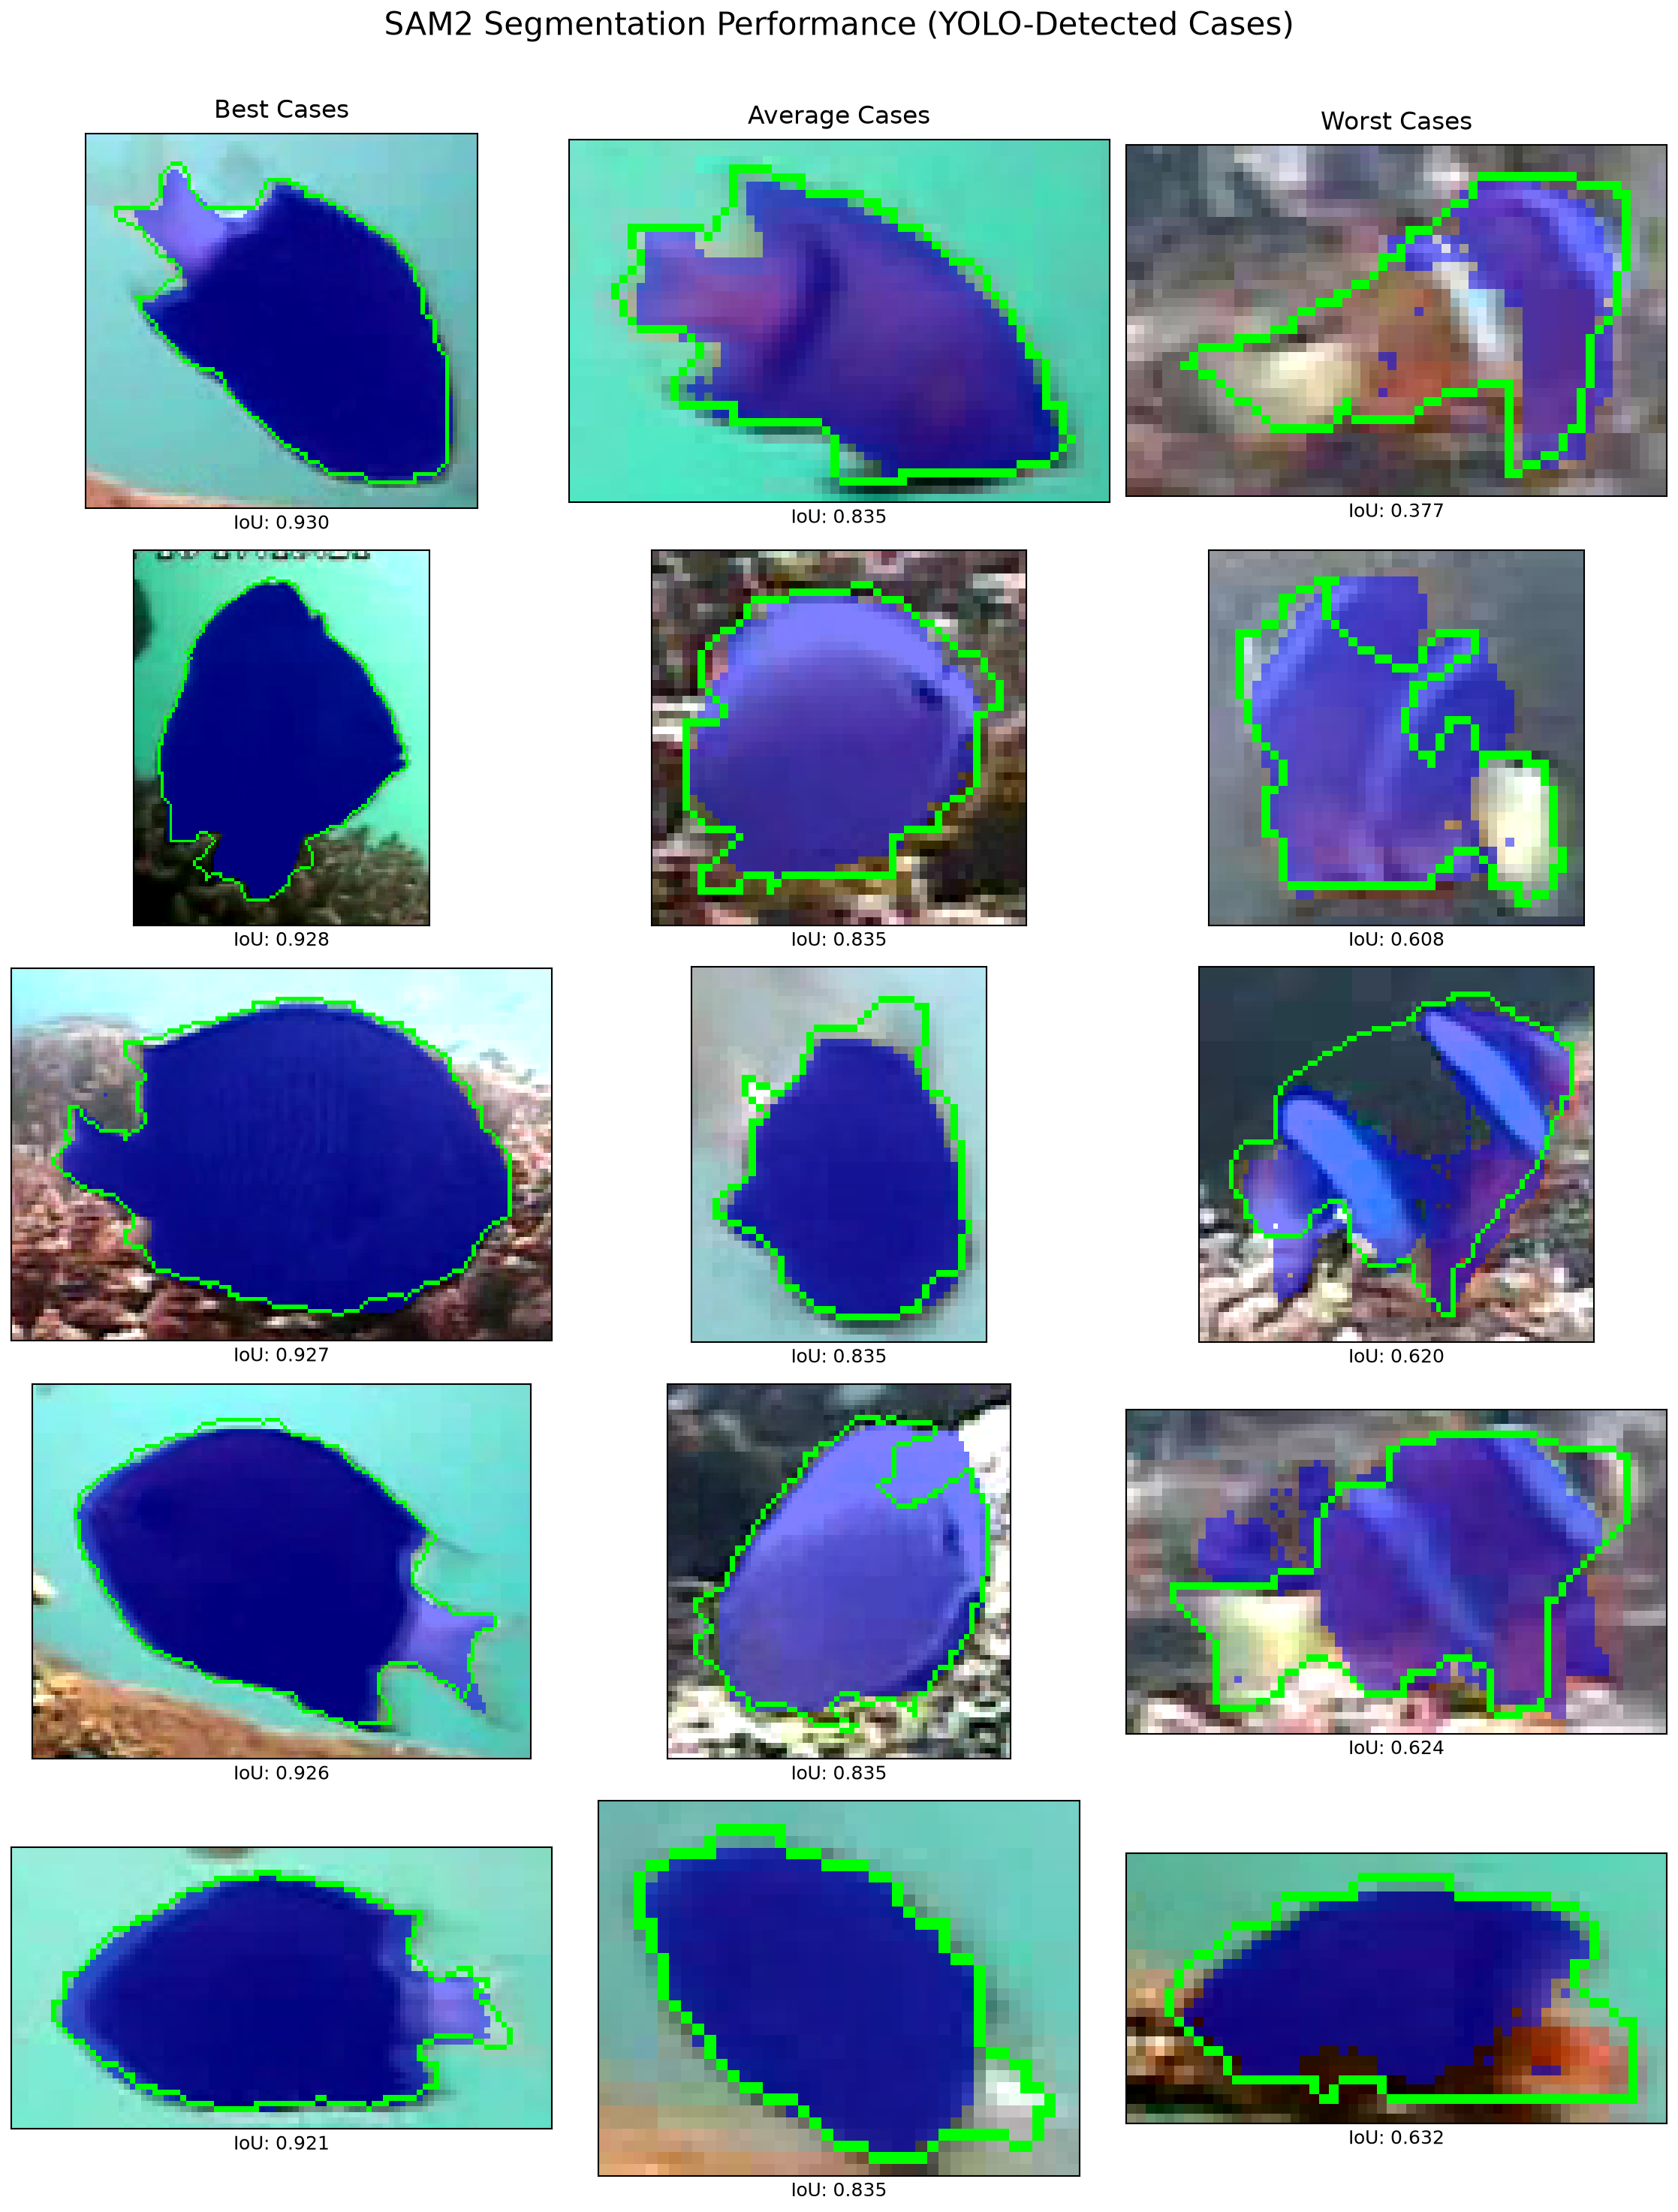

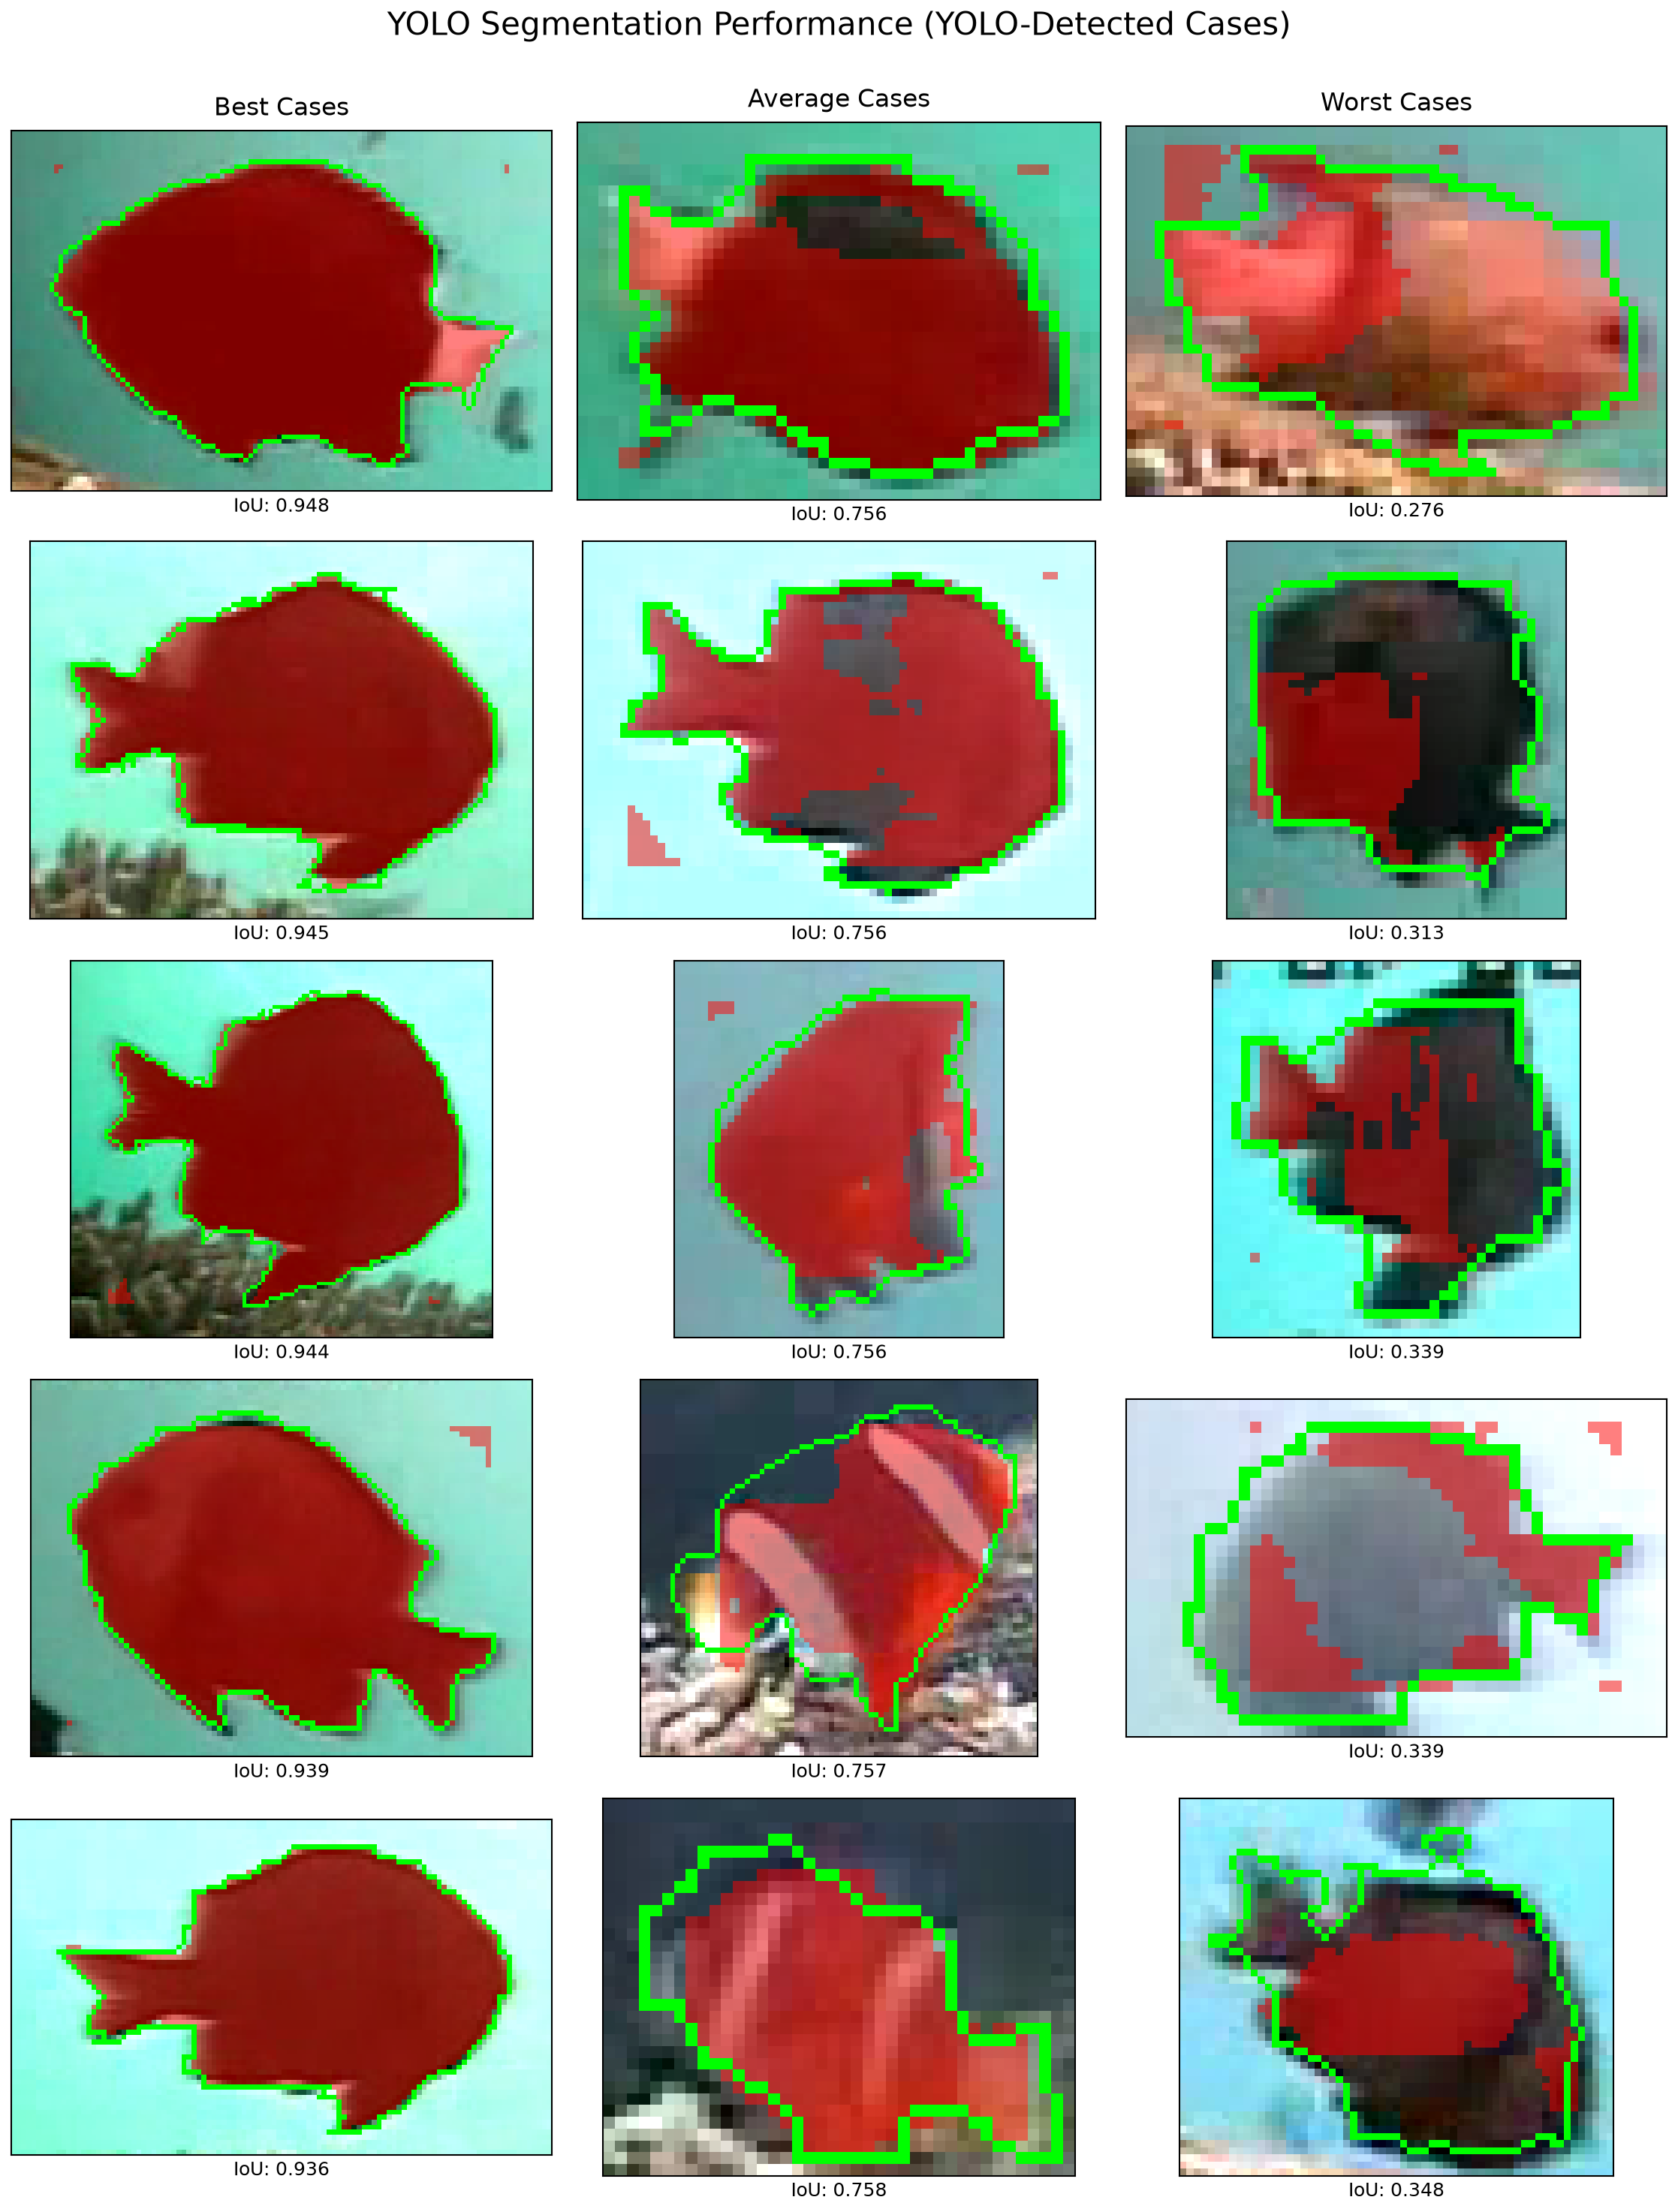

In [12]:


if __name__ == '__main__':
    # Define Directories
    IMAGE_DIR = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_instance_segmentation\cropped_untouched_images"
    LABEL_DIR = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_instance_segmentation\cropped_untouched_labels"
    VISUALS_DIR = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\results\segmentation\critical_cases"
    
    # Models
    YOLO_WEIGHTS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\segment\Fish_IS_Comparison\YOLO_Segmentation_Run7\weights\best.pt" 
    SAM2_CONFIG = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\weights\segmentation\segment-anything-2\sam2\configs\sam2.1\sam2.1_hiera_l.yaml"
    SAM_WEIGHTS_PATH = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\weights\segmentation\sam2.1_hiera_large.pt"
    
    evaluate_detected_cases_only(
        img_dir=IMAGE_DIR,
        label_dir=LABEL_DIR,
        yolo_weights=YOLO_WEIGHTS,
        sam2_checkpoint=SAM_WEIGHTS_PATH,
        sam2_config=SAM2_CONFIG
    )

In [ ]:
import time
import torch
import numpy as np

def benchmark_inference_times(yolo_model, sam2_predictor, img, bboxes, num_warmup=10, num_runs=50):
    """
    Measures and compares the inference latency of YOLO and SAM2.
    
    Args:
        yolo_model: Loaded Ultralytics YOLO model
        sam2_predictor: Initialized SAM2ImagePredictor
        img: OpenCV BGR image array
        bboxes: List of bounding boxes [x1, y1, x2, y2] to use as SAM2 prompts
        num_warmup: Iterations to warm up the hardware
        num_runs: Iterations to average the timing over
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    print(f"--- Benchmarking YOLO (Device: {device}) ---")
    # Warm-up phase
    for _ in range(num_warmup):
        _ = yolo_model.predict(img, retina_masks=True, verbose=False)
        
    yolo_times = []
    for _ in range(num_runs):
        if device.type == "cuda":
            start_evt = torch.cuda.Event(enable_timing=True)
            end_evt = torch.cuda.Event(enable_timing=True)
            
            start_evt.record()
            _ = yolo_model.predict(img, retina_masks=True, verbose=False)
            end_evt.record()
            
            torch.cuda.synchronize()
            yolo_times.append(start_evt.elapsed_time(end_evt))
        else:
            t0 = time.perf_counter()
            _ = yolo_model.predict(img, retina_masks=True, verbose=False)
            yolo_times.append((time.perf_counter() - t0) * 1000)
            
    print(f"YOLO Mean Inference Time: {np.mean(yolo_times):.2f} ms")


    print(f"\n--- Benchmarking SAM2 (Device: {device}) ---")
    # Warm-up phase
    for _ in range(num_warmup):
        sam2_predictor.set_image(img_rgb)
        for box in bboxes:
            _ = sam2_predictor.predict(box=box, multimask_output=False)
            
    sam2_encoder_times = []
    sam2_decoder_times = []
    
    for _ in range(num_runs):
        if device.type == "cuda":
            # Time the Image Encoder (Runs once per image)
            start_enc = torch.cuda.Event(enable_timing=True)
            end_enc = torch.cuda.Event(enable_timing=True)
            
            start_enc.record()
            sam2_predictor.set_image(img_rgb)
            end_enc.record()
            
            torch.cuda.synchronize()
            sam2_encoder_times.append(start_enc.elapsed_time(end_enc))
            
            # Time the Prompt Decoder (Runs per bounding box)
            start_dec = torch.cuda.Event(enable_timing=True)
            end_dec = torch.cuda.Event(enable_timing=True)
            
            start_dec.record()
            for box in bboxes:
                _ = sam2_predictor.predict(box=box, multimask_output=False)
            end_dec.record()
            
            torch.cuda.synchronize()
            sam2_decoder_times.append(start_dec.elapsed_time(end_dec))
        else:
            t0 = time.perf_counter()
            sam2_predictor.set_image(img_rgb)
            sam2_encoder_times.append((time.perf_counter() - t0) * 1000)
            
            t1 = time.perf_counter()
            for box in bboxes:
                _ = sam2_predictor.predict(box=box, multimask_output=False)
            sam2_decoder_times.append((time.perf_counter() - t1) * 1000)

    mean_enc = np.mean(sam2_encoder_times)
    mean_dec = np.mean(sam2_decoder_times)
    
    print(f"SAM2 Mean Image Encoder Time (set_image)        : {mean_enc:.2f} ms")
    print(f"SAM2 Mean Prompt Decoder Time (for {len(bboxes)} boxes)    : {mean_dec:.2f} ms")
    print(f"SAM2 Total Mean Inference Time (Enc + Dec)      : {mean_enc + mean_dec:.2f} ms")

# ==========================================
# Example Usage:
# ==========================================
test_img = cv2.imread(r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\data\processed\test_set_instance_segmentation\cropped_untouched_images\fish_01_000000009598_05283_crop_0.png")
test_bboxes = [[10, 10, 110, 110]] # Mock bounding boxes
YOLO_WEIGHTS = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\ultralytics\runs\segment\Fish_IS_Comparison\YOLO_Segmentation_Run7\weights\best.pt" 
SAM2_CONFIG = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\weights\segmentation\segment-anything-2\sam2\configs\sam2.1\sam2.1_hiera_l.yaml"
SAM_WEIGHTS_PATH = r"C:\Users\julie\Desktop\LOUIS\5EOTF50-Master-Thesis-Project-main\weights\segmentation\sam2.1_hiera_large.pt"
yolo_model = YOLO(YOLO_WEIGHTS)
sam2_model = build_sam2(SAM2_CONFIG, SAM_WEIGHTS_PATH, device=torch.device("cuda" if torch.cuda.is_available() else "cpu"))
sam2_predictor = SAM2ImagePredictor(sam2_model)
benchmark_inference_times(yolo_model, sam2_predictor, test_img, test_bboxes)

--- Benchmarking YOLO (Device: cuda) ---
YOLO Mean Inference Time: 160.78 ms

--- Benchmarking SAM2 (Device: cuda) ---
SAM2 Mean Image Encoder Time (set_image)        : 1305.47 ms
SAM2 Mean Prompt Decoder Time (for 2 boxes)    : 129.43 ms
SAM2 Total Mean Inference Time (Enc + Dec)      : 1434.89 ms
